In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [7]:
df_snapshot = pd.read_csv('/Users/tyco/Desktop/MADS/sanovo_19052025/data/processed/data_snapshots.csv')

In [8]:
# Convert MerDateDay to datetime if not already done
df_snapshot['MerDate'] = pd.to_datetime(df_snapshot['MerDate'] )

# Filter out weekend dates (Saturday and Sunday)
df_snapshot = df_snapshot[~df_snapshot['MerDate'].dt.weekday.isin([5, 6])]

In [9]:
df_snapshot['time_in_seconds'] = pd.to_timedelta(df_snapshot['time_delta']).dt.total_seconds()
df_snapshot.head()

,index,MerDate,MerId,MerType,MerNumber,MerSubNumber,MerData1,MerData2,MerData3,MerData4,...,MerMinId,MerText,MerDeviceType,MerDeviceNumber,MerPriority,Error/warnings,lane_stopping_machine,snapshot,time_delta,time_in_seconds
0,0,2025-01-30 10:21:42,11897186,21,460,12,1.0,22.0,41.0,NaN,...,4620,NaN,0,0,0,21_460_22.0_41.0,NaN,1,0 days 00:04:02,242.0
1,1,2025-01-30 10:21:56,11897187,23,460,12,0.0,0.0,0.0,NaN,...,4620,NaN,0,0,0,23_460_0.0_0.0,NaN,1,0 days 00:04:02,242.0
2,2,2025-01-30 10:21:56,11897188,21,460,12,1.0,22.0,41.0,NaN,...,4620,NaN,0,0,0,21_460_22.0_41.0,NaN,1,0 days 00:04:02,242.0
3,3,2025-01-30 10:21:57,11897189,23,460,12,0.0,0.0,0.0,NaN,...,4620,NaN,0,0,0,23_460_0.0_0.0,NaN,1,0 days 00:04:02,242.0
4,4,2025-01-30 10:21:57,11897190,21,460,12,1.0,22.0,41.0,NaN,...,4620,NaN,0,0,0,21_460_22.0_41.0,NaN,1,0 days 00:04:02,242.0


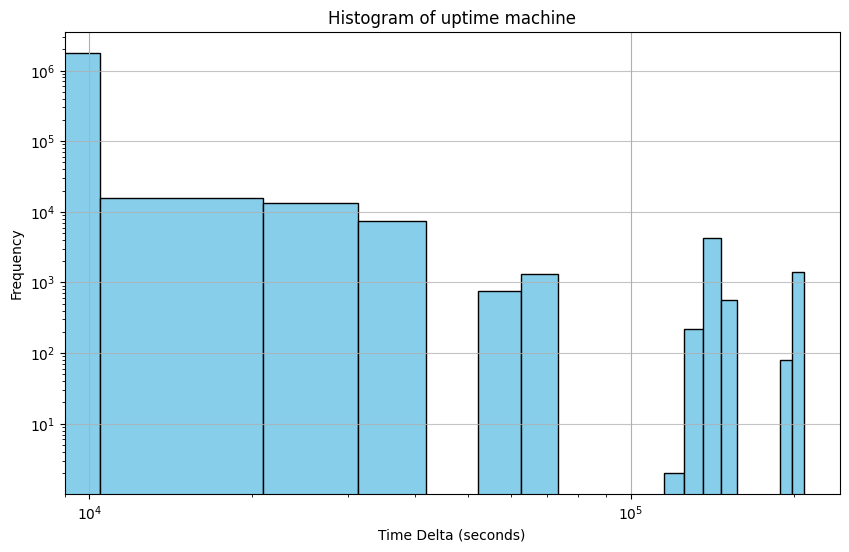

In [17]:
plt.figure(figsize=(10, 6))
df_snapshot['time_in_seconds'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of uptime machine')
plt.xlabel('Time Delta (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.xscale('log')
plt.yscale('log')
plt.show()

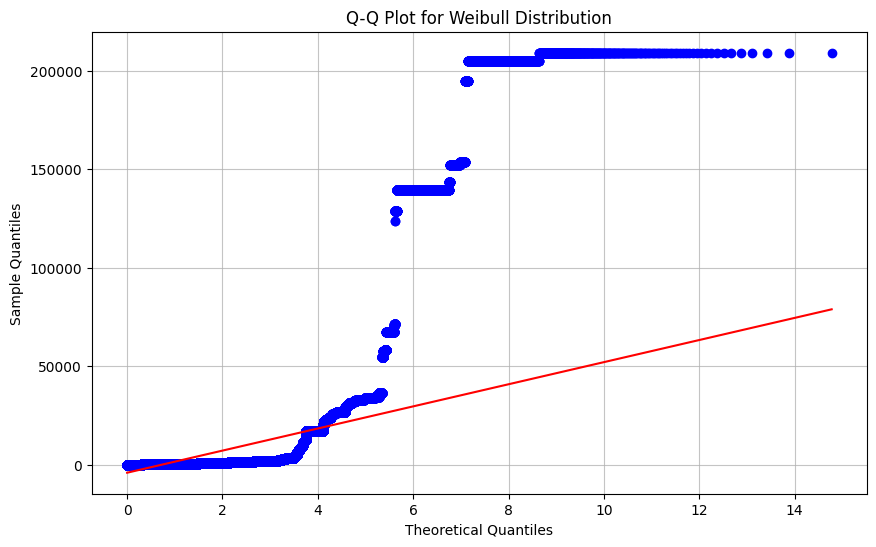

In [20]:
from scipy.stats import probplot

import matplotlib.pyplot as plt

# Generate a Q-Q plot for the Weibull distribution
plt.figure(figsize=(10, 6))
probplot(df_snapshot['time_in_seconds'], dist="weibull_min", sparams=(1,), plot=plt)
plt.title('Q-Q Plot for Weibull Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(alpha=0.75)
plt.show()

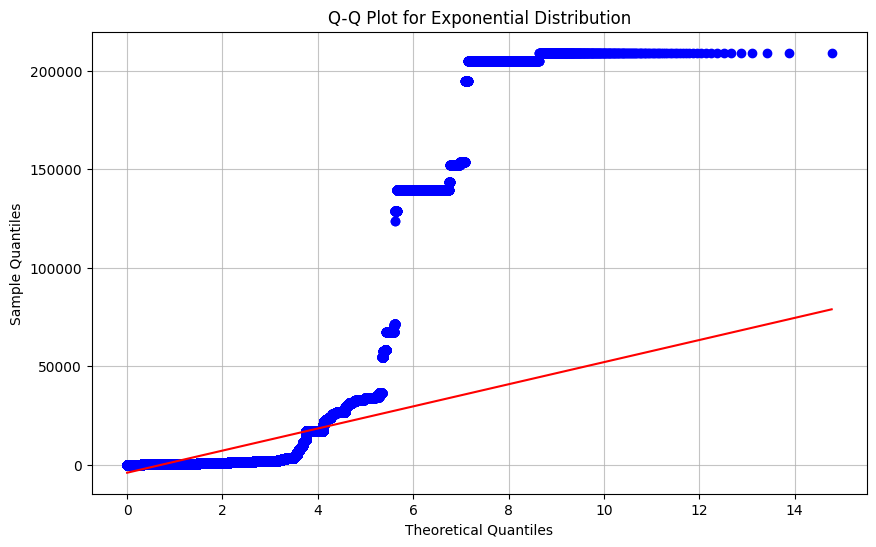

In [21]:
# Generate a Q-Q plot for the Exponential distribution
plt.figure(figsize=(10, 6))
probplot(df_snapshot['time_in_seconds'], dist="expon", plot=plt)
plt.title('Q-Q Plot for Exponential Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(alpha=0.75)
plt.show()

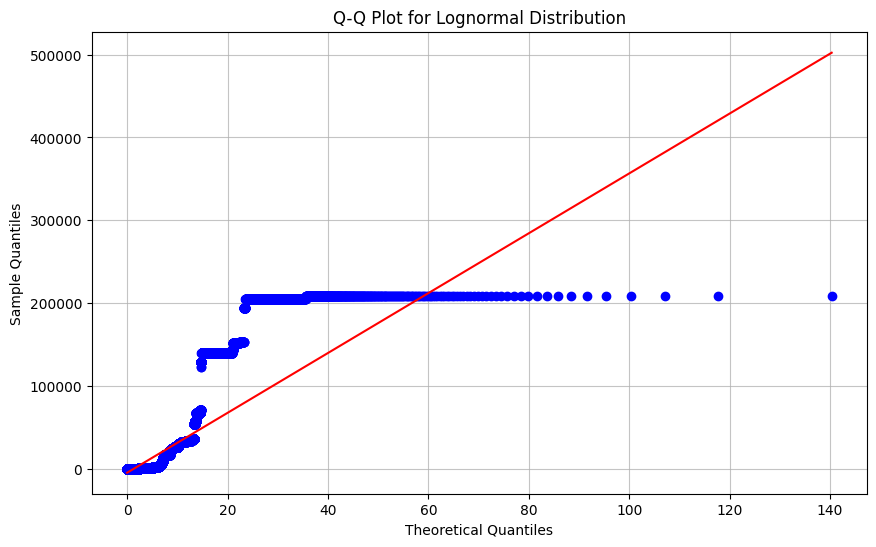

In [22]:
# Generate a Q-Q plot for the Lognormal distribution
plt.figure(figsize=(10, 6))
probplot(df_snapshot['time_in_seconds'], dist="lognorm", sparams=(1,), plot=plt)
plt.title('Q-Q Plot for Lognormal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.grid(alpha=0.75)
plt.show()

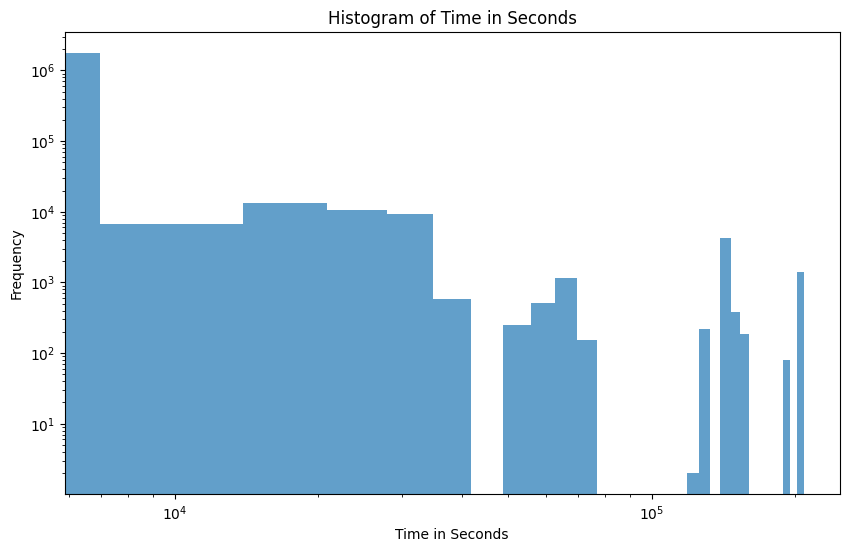

In [13]:
# Create a histogram for the 'time_in_seconds' column
plt.figure(figsize=(10, 6))
df_snapshot['time_in_seconds'].plot.hist(bins=30, alpha=0.7)
plt.title('Histogram of Time in Seconds')
plt.xlabel('Time in Seconds')
plt.ylabel('Frequency')
plt.xscale('log')
plt.yscale('log')
plt.show()

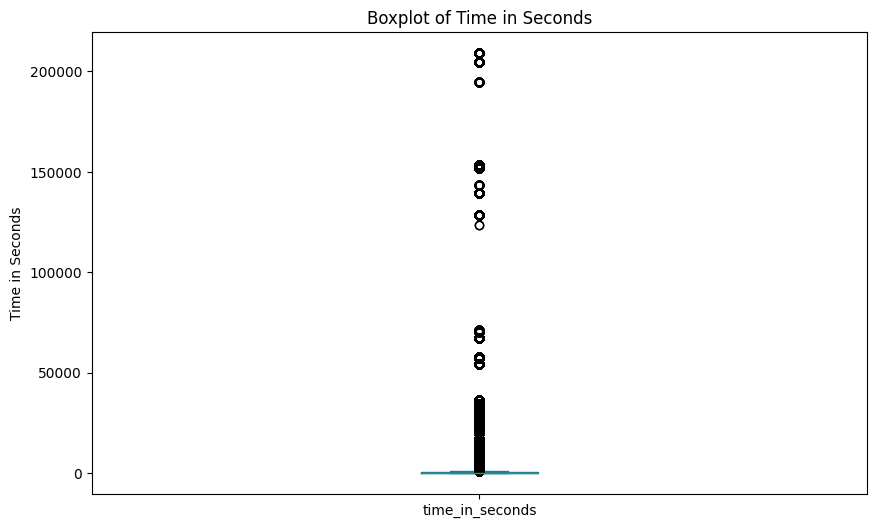

In [10]:
import matplotlib.pyplot as plt

# Create a boxplot for the 'time_in_seconds' column
plt.figure(figsize=(10, 6))
df_snapshot['time_in_seconds'].plot.box()
plt.title('Boxplot of Time in Seconds')
plt.ylabel('Time in Seconds')
plt.show()